In [13]:
import pandas as pd
import re

# --------------------------------------------------
# 1. Load CSV (skip report-generated line)
# --------------------------------------------------
df = pd.read_csv(
    "GlobalEnergyProductionDataset1980-2023.csv",
    skiprows=1
)

# Rename the country/name column safely
df = df.rename(columns={"Unnamed: 1": "country"})

# --------------------------------------------------
# 2. Detect year columns robustly
# --------------------------------------------------
year_cols = [
    c for c in df.columns
    if re.fullmatch(r"(19|20)\d{2}", str(c))
]

if not year_cols:
    raise ValueError("❌ No year columns detected")

# --------------------------------------------------
# 3. Detect energy section headers (THIS WAS THE KEY)
# --------------------------------------------------
df["energy_type"] = None

energy_map = {
    "total energy production (quad btu)": "total_energy",
    "total energy production from coal (quad btu)": "coal",
    "total energy production from natural gas (quad btu)": "natural_gas",
    "total energy production from petroleum and other liquids (quad btu)": "petroleum",
    "total energy production from nuclear, renewables, and other (quad btu)": "nuclear_renewables_other",
    "total energy production from nuclear (quad btu)": "nuclear",
    "total energy production from renewables and other (quad btu)": "renewables_other",
}

country_lower = df["country"].astype(str).str.lower()

for text, label in energy_map.items():
    df.loc[country_lower == text, "energy_type"] = label

# Forward-fill energy type within each block
df["energy_type"] = df["energy_type"].ffill()

# --------------------------------------------------
# 4. Keep ONLY real country rows
# --------------------------------------------------
df = df[df["API"].notna()].copy()

df["country"] = df["country"].str.strip()

# --------------------------------------------------
# 5. Clean missing values
# --------------------------------------------------
df.replace(["--", "—", ""], pd.NA, inplace=True)

# --------------------------------------------------
# 6. Wide → Long
# --------------------------------------------------
long_df = df.melt(
    id_vars=["country", "energy_type"],
    value_vars=year_cols,
    var_name="year",
    value_name="value"
)

long_df["year"] = long_df["year"].astype(int)
long_df["value"] = pd.to_numeric(long_df["value"], errors="coerce")

# --------------------------------------------------
# 7. Pivot to final tidy panel
# --------------------------------------------------
panel_df = long_df.pivot_table(
    index=["country", "year"],
    columns="energy_type",
    values="value"
).reset_index()

panel_df.columns.name = None
panel_df = panel_df.sort_values(["country", "year"])

# --------------------------------------------------
# 8. Save final dataset
# --------------------------------------------------
panel_df.to_csv(
    "global_energy_panel_1980_2023.csv",
    index=False
)

print("✅ SUCCESS: Dataset created")
print(panel_df.head())
print(panel_df.shape)


✅ SUCCESS: Dataset created
       country  year      coal  natural_gas  nuclear  \
0  Afghanistan  1980  0.002355     0.062820      0.0   
1  Afghanistan  1981  0.002474     0.082713      0.0   
2  Afghanistan  1982  0.002870     0.084807      0.0   
3  Afghanistan  1983  0.002870     0.088995      0.0   
4  Afghanistan  1984  0.002929     0.088995      0.0   

   nuclear_renewables_other  petroleum  renewables_other  total_energy  
0                  0.002426        0.0          0.002426      0.067601  
1                  0.002460        0.0          0.002460      0.087647  
2                  0.002412        0.0          0.002412      0.090089  
3                  0.002545        0.0          0.002545      0.094410  
4                  0.002583        0.0          0.002583      0.094507  
(9489, 9)


In [16]:
import pandas as pd

# --------------------------------------------------
# Load Annual Data sheet (raw, no headers)
# --------------------------------------------------
df = pd.read_excel(
    "Renewable_Energy_Production_and_Consumption_by_Source.xlsx",
    sheet_name="Monthly Data",
    header=None
)

# --------------------------------------------------
# Remove useless rows
# - First 10 rows  -> indices 0–9
# - 12th row       -> index 11 (0-based indexing)
# --------------------------------------------------
df = df.drop(index=list(range(0, 10)) + [11])

# --------------------------------------------------
# Reset index after row removal
# --------------------------------------------------
df = df.reset_index(drop=True)

# --------------------------------------------------
# Save cleaned file
# --------------------------------------------------
df.to_excel(
    "Renewable_Energy_Monthly_Cleaned.xlsx",
    index=False,
    header=False
)

print("✅ Rows removed successfully")
print(df.head())


✅ Rows removed successfully
                    0                       1                    2   \
0                Month  Wood Energy Production  Biofuels Production   
1  1973-01-01 00:00:00                  129.63        Not Available   
2  1973-02-01 00:00:00                 117.194        Not Available   
3  1973-03-01 00:00:00                 129.763        Not Available   
4  1973-04-01 00:00:00                 125.462        Not Available   

                                3                                  4   \
0  Total Biomass Energy Production  Total Renewable Energy Production   
1                          129.787                            219.839   
2                          117.338                             197.33   
3                          129.938                            218.686   
4                          125.636                             209.33   

                                5                              6   \
0  Hydroelectric Power Consumption  G

In [18]:
import pandas as pd

# --------------------------------------------------
# 1. Load cleaned monthly dataset
# --------------------------------------------------
df = pd.read_excel("Renewable_Energy_Monthly_Cleaned.xlsx")

# --------------------------------------------------
# 2. Ensure Month column is datetime & ordered
# --------------------------------------------------
df["Month"] = pd.to_datetime(df["Month"])
df = df.sort_values("Month").reset_index(drop=True)

# --------------------------------------------------
# 3. Convert EIA missing markers safely
#    (NO imputation, just text → NaN)
# --------------------------------------------------
df.replace("Not Available", pd.NA, inplace=True)

# --------------------------------------------------
# 4. Missing value check (bias prevention)
# --------------------------------------------------
missing_summary = df.isna().mean().sort_values(ascending=False)
print("\nShare of missing values per variable:")
print(missing_summary)

# --------------------------------------------------
# 5. Temporal continuity check (monthly sequence)
# --------------------------------------------------
full_range = pd.date_range(
    start=df["Month"].min(),
    end=df["Month"].max(),
    freq="MS"
)

missing_months = full_range.difference(df["Month"])

print("\nMissing months:")
print(missing_months)

# --------------------------------------------------
# 6. Duplicate month check
# --------------------------------------------------
duplicate_months = df["Month"].duplicated().sum()
print(f"\nDuplicate months: {duplicate_months}")

# --------------------------------------------------
# 7. Numeric sanity check (no outlier removal)
# --------------------------------------------------
numeric_cols = df.columns.drop("Month")

df[numeric_cols] = df[numeric_cols].apply(
    pd.to_numeric, errors="coerce"
)

print("\nSummary statistics (numeric columns):")
print(df[numeric_cols].describe())

# --------------------------------------------------
# 8. Final confirmation
# --------------------------------------------------
if missing_months.empty and duplicate_months == 0:
    print("\n✅ Data Preprocessing & Quality Checks PASSED")
else:
    print("\n⚠ Issues detected — report but DO NOT impute")



Share of missing values per variable:
Solar Energy Consumption              0.208531
Wind Energy Consumption               0.189573
Biofuels Production                   0.151659
Biofuels Consumption                  0.151659
Wood Energy Production                0.000000
Month                                 0.000000
Hydroelectric Power Consumption       0.000000
Total Renewable Energy Production     0.000000
Total Biomass Energy Production       0.000000
Geothermal Energy Consumption         0.000000
Wood Energy Consumption               0.000000
Waste Energy Consumption              0.000000
Total Biomass Energy Consumption      0.000000
Total Renewable Energy Consumption    0.000000
dtype: float64

Missing months:
DatetimeIndex([], dtype='datetime64[ns]', freq='MS')

Duplicate months: 0

Summary statistics (numeric columns):
       Wood Energy Production  Biofuels Production  \
count              633.000000           537.000000   
mean               184.393908            85.444013

In [19]:
import pandas as pd

# --------------------------------------------------
# 1. Load global annual dataset
# --------------------------------------------------
panel = pd.read_csv("global_energy_panel_1980_2023.csv")

# --------------------------------------------------
# 2. Missing value overview
# --------------------------------------------------
print("\nShare of missing values per variable:")
print(panel.isna().mean().sort_values(ascending=False))

# --------------------------------------------------
# 3. Duplicate country–year check
# --------------------------------------------------
duplicates = panel.duplicated(subset=["country", "year"]).sum()
print(f"\nDuplicate country–year observations: {duplicates}")

# --------------------------------------------------
# 4. Temporal continuity check (per country)
# --------------------------------------------------
year_gaps = (
    panel.sort_values(["country", "year"])
         .groupby("country")["year"]
         .apply(lambda x: (x.diff().dropna() != 1).any())
)

print("\nCountries with year gaps:")
print(year_gaps[year_gaps].index.tolist())

# --------------------------------------------------
# 5. Numeric sanity check
# --------------------------------------------------
numeric_cols = panel.columns.drop(["country", "year"])

print("\nSummary statistics (numeric columns):")
print(panel[numeric_cols].describe())



Share of missing values per variable:
nuclear                     0.014227
natural_gas                 0.005480
total_energy                0.000422
renewables_other            0.000105
nuclear_renewables_other    0.000105
country                     0.000000
coal                        0.000000
year                        0.000000
petroleum                   0.000000
dtype: float64

Duplicate country–year observations: 0

Countries with year gaps:
[]

Summary statistics (numeric columns):
              coal  natural_gas      nuclear  nuclear_renewables_other  \
count  9489.000000  9437.000000  9354.000000              9.488000e+03   
mean      1.139203     0.921313     0.214636              3.841758e-01   
std       9.631551     7.384192     1.711040              3.122792e+00   
min       0.000000     0.000000     0.000000             -1.000000e-39   
25%       0.000000     0.000000     0.000000              6.824283e-06   
50%       0.000000     0.000000     0.000000              2.

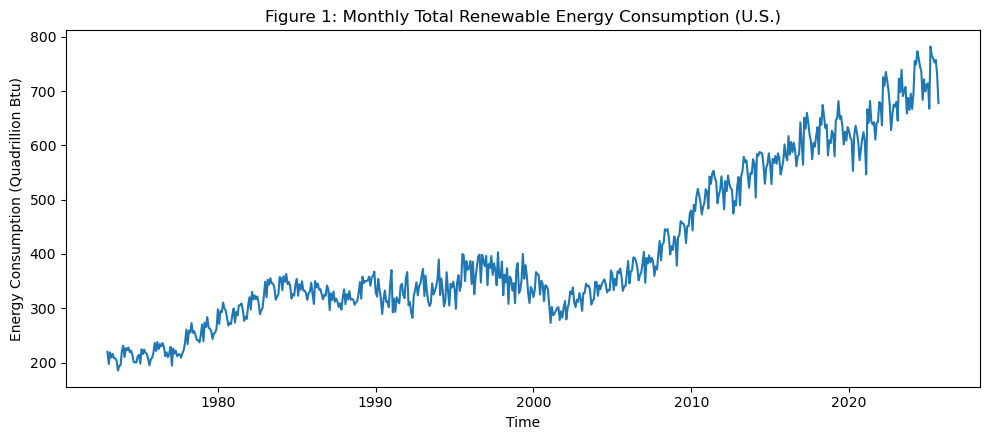

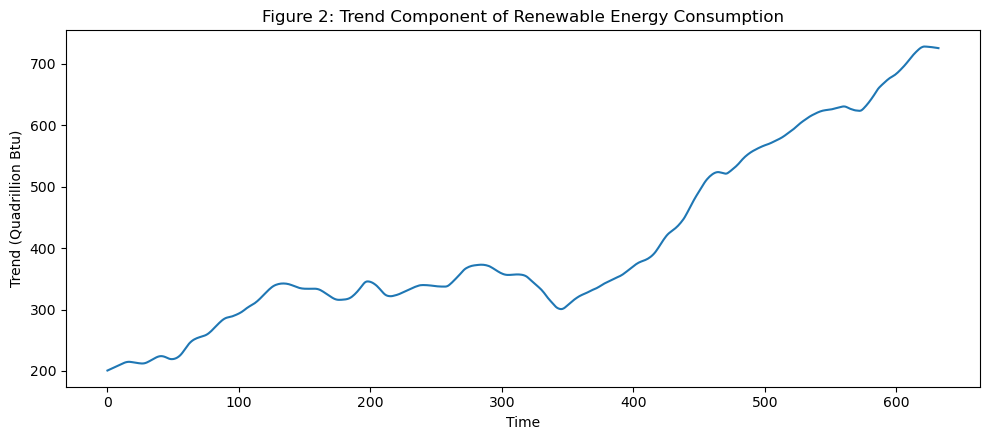

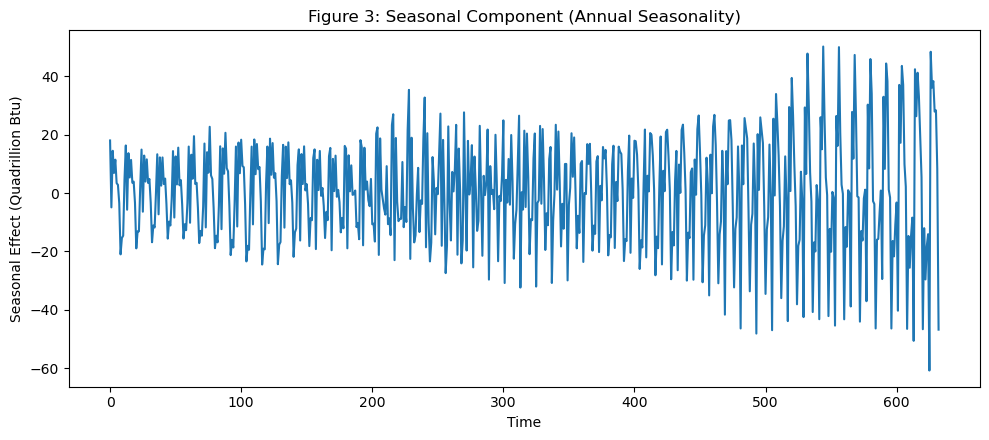

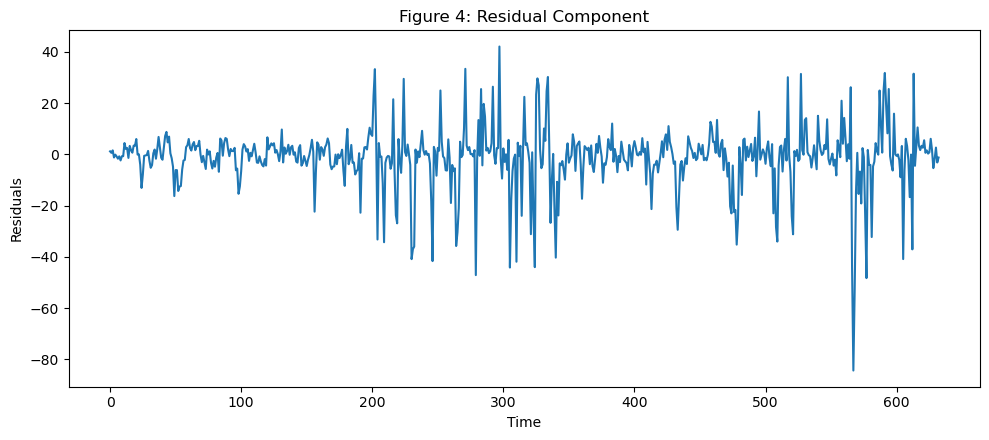

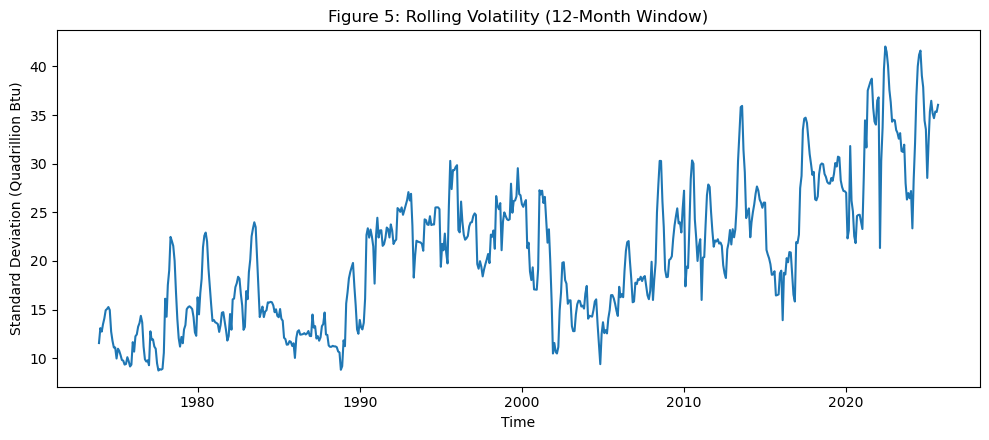

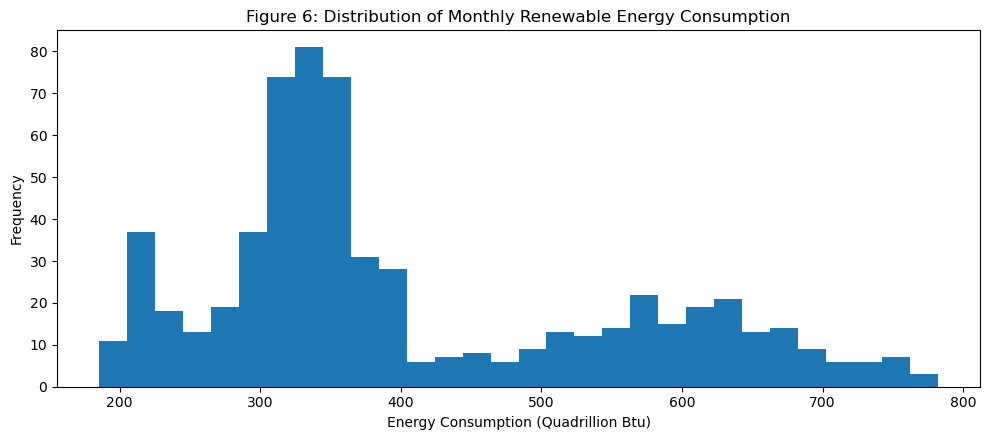

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import STL

# --------------------------------------------------
# Load data
# --------------------------------------------------
df = pd.read_excel("Renewable_Energy_Monthly_Cleaned.xlsx")
df["Month"] = pd.to_datetime(df["Month"])
df = df.sort_values("Month")

y = df["Total Renewable Energy Consumption"]

# --------------------------------------------------
# Figure 1: Time series
# --------------------------------------------------
plt.figure(figsize=(10, 4.5))
plt.plot(df["Month"], y)
plt.title("Figure 1: Monthly Total Renewable Energy Consumption (U.S.)")
plt.xlabel("Time")
plt.ylabel("Energy Consumption (Quadrillion Btu)")
plt.tight_layout()
plt.savefig("fig_1_monthly_renewable_consumption.png", dpi=300)
plt.show()

# --------------------------------------------------
# STL decomposition
# --------------------------------------------------
stl = STL(y, period=12, robust=True)
res = stl.fit()

# Figure 2: Trend
plt.figure(figsize=(10, 4.5))
res.trend.plot()
plt.title("Figure 2: Trend Component of Renewable Energy Consumption")
plt.xlabel("Time")
plt.ylabel("Trend (Quadrillion Btu)")
plt.tight_layout()
plt.savefig("fig_2_trend_component.png", dpi=300)
plt.show()

# Figure 3: Seasonality
plt.figure(figsize=(10, 4.5))
res.seasonal.plot()
plt.title("Figure 3: Seasonal Component (Annual Seasonality)")
plt.xlabel("Time")
plt.ylabel("Seasonal Effect (Quadrillion Btu)")
plt.tight_layout()
plt.savefig("fig_3_seasonal_component.png", dpi=300)
plt.show()

# Figure 4: Residuals
plt.figure(figsize=(10, 4.5))
res.resid.plot()
plt.title("Figure 4: Residual Component")
plt.xlabel("Time")
plt.ylabel("Residuals")
plt.tight_layout()
plt.savefig("fig_4_residuals.png", dpi=300)
plt.show()

# --------------------------------------------------
# Figure 5: Rolling volatility
# --------------------------------------------------
rolling_std = y.rolling(12).std()

plt.figure(figsize=(10, 4.5))
plt.plot(df["Month"], rolling_std)
plt.title("Figure 5: Rolling Volatility (12-Month Window)")
plt.xlabel("Time")
plt.ylabel("Standard Deviation (Quadrillion Btu)")
plt.tight_layout()
plt.savefig("fig_5_rolling_volatility.png", dpi=300)
plt.show()

# --------------------------------------------------
# Figure 6: Distribution
# --------------------------------------------------
plt.figure(figsize=(10, 4.5))
plt.hist(y, bins=30)
plt.title("Figure 6: Distribution of Monthly Renewable Energy Consumption")
plt.xlabel("Energy Consumption (Quadrillion Btu)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig("fig_6_distribution.png", dpi=300)
plt.show()


In [29]:
# ==================================================
# BASELINE FORECASTING MODELS
# SARIMA | ETS | STL-ARIMA
# ==================================================

import pandas as pd
import numpy as np

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.seasonal import STL

from sklearn.metrics import mean_absolute_error, mean_squared_error

# --------------------------------------------------
# 1. Load data
# --------------------------------------------------
df = pd.read_excel("Renewable_Energy_Monthly_Cleaned.xlsx")

df["Month"] = pd.to_datetime(df["Month"])
df = df.sort_values("Month").set_index("Month")

y = df["Total Renewable Energy Consumption"]

# --------------------------------------------------
# 2. Train / Test split (no leakage)
# --------------------------------------------------
train = y.loc[: "2021-12-01"]
test  = y.loc["2022-01-01" :]

h = len(test)

# --------------------------------------------------
# 3. Evaluation function
# --------------------------------------------------
def evaluate(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred))
    }

# --------------------------------------------------
# 4. SARIMA
# --------------------------------------------------
sarima = SARIMAX(
    train,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_fit = sarima.fit(disp=False)
sarima_forecast = sarima_fit.forecast(steps=h)
sarima_results = evaluate(test, sarima_forecast)

# --------------------------------------------------
# 5. ETS (Error-Trend-Seasonal)
# --------------------------------------------------
ets = ExponentialSmoothing(
    train,
    trend="add",
    seasonal="add",
    seasonal_periods=12
)

ets_fit = ets.fit()
ets_forecast = ets_fit.forecast(h)
ets_results = evaluate(test, ets_forecast)

# --------------------------------------------------
# 6. STL-ARIMA
# --------------------------------------------------
stl = STL(train, period=12, robust=True)
stl_res = stl.fit()

trend = stl_res.trend
seasonal = stl_res.seasonal
residual = stl_res.resid.dropna()

resid_model = SARIMAX(
    residual,
    order=(1, 0, 1),
    enforce_stationarity=False,
    enforce_invertibility=False
)

resid_fit = resid_model.fit(disp=False)
resid_forecast = resid_fit.forecast(steps=h)

seasonal_forecast = np.tile(seasonal[-12:], h // 12 + 1)[:h]
trend_forecast = np.repeat(trend.iloc[-1], h)

stl_arima_forecast = trend_forecast + seasonal_forecast + resid_forecast.values
stl_arima_results = evaluate(test, stl_arima_forecast)

# --------------------------------------------------
# 7. Results table
# --------------------------------------------------
results = pd.DataFrame.from_dict(
    {
        "SARIMA": sarima_results,
        "ETS": ets_results,
        "STL-ARIMA": stl_arima_results
    },
    orient="index"
)

print("\nBaseline Forecasting Results:")
print(results)


C:\Users\Kamal_FOM\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Kamal_FOM\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Kamal_FOM\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)



Baseline Forecasting Results:
                 MAE       RMSE
SARIMA     25.731714  31.166847
ETS        29.445380  35.826681
STL-ARIMA  58.542356  65.441429


C:\Users\Kamal_FOM\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Kamal_FOM\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


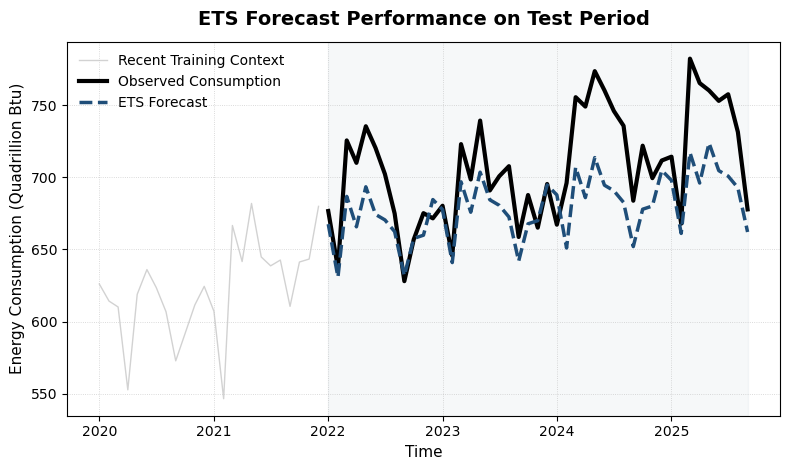

In [40]:
import matplotlib.pyplot as plt

# --------------------------------------------------
# Outstanding ETS Visualization (Publication Grade)
# --------------------------------------------------

fig, ax = plt.subplots(figsize=(8, 4.8))

# --- Background: faint training context (last 3 years only)
context_window = 24
ax.plot(
    train.index[-context_window:],
    train[-context_window:],
    color="#c7c7c7",
    linewidth=1,
    alpha=0.8,
    label="Recent Training Context"
)

# --- Actual values (dominant)
ax.plot(
    test.index,
    test,
    color="#000000",
    linewidth=3,
    label="Observed Consumption"
)

# --- ETS forecast (contrast, elegant)
ax.plot(
    test.index,
    ets_forecast,
    color="#1f4e79",
    linewidth=2.5,
    linestyle="--",
    label="ETS Forecast"
)

# --- Test period highlight (very subtle)
ax.axvspan(
    test.index.min(),
    test.index.max(),
    color="#1f4e79",
    alpha=0.04
)

# --- Labels & title
ax.set_title(
    "ETS Forecast Performance on Test Period",
    fontsize=14,
    fontweight="bold",
    pad=12
)
ax.set_xlabel("Time", fontsize=11)
ax.set_ylabel("Energy Consumption (Quadrillion Btu)", fontsize=11)

# --- Grid (subtle, professional)
ax.grid(True, linestyle=":", linewidth=0.6, alpha=0.6)

# --- Legend (clean)
ax.legend(
    frameon=False,
    fontsize=10,
    loc="upper left"
)

# --- Tight layout & export
plt.tight_layout()
plt.savefig("fig_ets_forecast_outstanding.png", dpi=300)
plt.show()


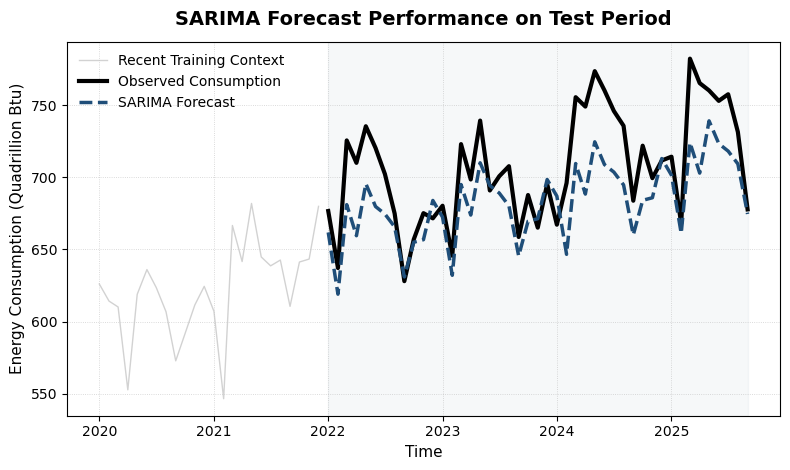

In [41]:
import matplotlib.pyplot as plt

# --------------------------------------------------
# SARIMA Forecast – Publication-Quality Visualization
# --------------------------------------------------

fig, ax = plt.subplots(figsize=(8, 4.8))

# Context: last 24 months of training
context_window = 24
ax.plot(
    train.index[-context_window:],
    train[-context_window:],
    color="#c7c7c7",
    linewidth=1,
    alpha=0.8,
    label="Recent Training Context"
)

# Actual test values (dominant)
ax.plot(
    test.index,
    test,
    color="black",
    linewidth=3,
    label="Observed Consumption"
)

# SARIMA forecast
ax.plot(
    test.index,
    sarima_forecast,
    color="#1f4e79",
    linestyle="--",
    linewidth=2.5,
    label="SARIMA Forecast"
)

# Subtle test-period highlight
ax.axvspan(
    test.index.min(),
    test.index.max(),
    color="#1f4e79",
    alpha=0.04
)

# Labels & title
ax.set_title(
    "SARIMA Forecast Performance on Test Period",
    fontsize=14,
    fontweight="bold",
    pad=12
)
ax.set_xlabel("Time", fontsize=11)
ax.set_ylabel("Energy Consumption (Quadrillion Btu)", fontsize=11)

# Grid
ax.grid(True, linestyle=":", linewidth=0.6, alpha=0.6)

# Legend
ax.legend(frameon=False, fontsize=10, loc="upper left")

# Export
plt.tight_layout()
plt.savefig("fig_sarima_forecast_outstanding.png", dpi=300)
plt.show()


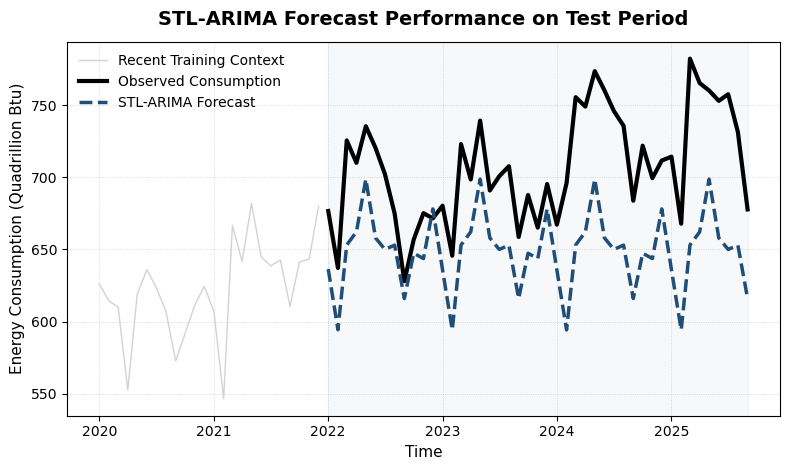

In [42]:
import matplotlib.pyplot as plt

# --------------------------------------------------
# STL-ARIMA Forecast – Publication-Quality Visualization
# --------------------------------------------------

fig, ax = plt.subplots(figsize=(8, 4.8))

# Context: last 24 months of training
context_window = 24
ax.plot(
    train.index[-context_window:],
    train[-context_window:],
    color="#c7c7c7",
    linewidth=1,
    alpha=0.8,
    label="Recent Training Context"
)

# Actual test values
ax.plot(
    test.index,
    test,
    color="black",
    linewidth=3,
    label="Observed Consumption"
)

# STL-ARIMA forecast
ax.plot(
    test.index,
    stl_arima_forecast,
    color="#1f4e79",
    linestyle="--",
    linewidth=2.5,
    label="STL-ARIMA Forecast"
)

# Subtle test-period highlight
ax.axvspan(
    test.index.min(),
    test.index.max(),
    color="#1f4e79",
    alpha=0.04
)

# Labels & title
ax.set_title(
    "STL-ARIMA Forecast Performance on Test Period",
    fontsize=14,
    fontweight="bold",
    pad=12
)
ax.set_xlabel("Time", fontsize=11)
ax.set_ylabel("Energy Consumption (Quadrillion Btu)", fontsize=11)

# Grid
ax.grid(True, linestyle=":", linewidth=0.6, alpha=0.6)

# Legend
ax.legend(frameon=False, fontsize=10, loc="upper left")

# Export
plt.tight_layout()
plt.savefig("fig_stl_arima_forecast_outstanding.png", dpi=300)
plt.show()


In [44]:
# ==================================================
# LSTM BASELINE (UNIVARIATE, FAIR COMPARISON)
# ==================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping

# --------------------------------------------------
# 1. Prepare data
# --------------------------------------------------
series = y.values.reshape(-1, 1)

scaler = MinMaxScaler()
scaled_series = scaler.fit_transform(series)

# Look-back window (12 months)
lookback = 12

def create_sequences(data, lookback):
    X, y = [], []
    for i in range(len(data) - lookback):
        X.append(data[i:i+lookback])
        y.append(data[i+lookback])
    return np.array(X), np.array(y)

X, y_lstm = create_sequences(scaled_series, lookback)

# Align with time index
dates = df.index[lookback:]

lstm_df = pd.DataFrame(
    y_lstm.flatten(),
    index=dates,
    columns=["value"]
)

# --------------------------------------------------
# 2. Train / Test split (aligned with earlier choice)
# --------------------------------------------------
train_mask = lstm_df.index <= "2021-12-01"

X_train = X[train_mask]
y_train = y_lstm[train_mask]

X_test = X[~train_mask]
y_test = y_lstm[~train_mask]


# --------------------------------------------------
# 3. LSTM model (simple & fair)
# --------------------------------------------------
model = Sequential([
    LSTM(32, activation="tanh", input_shape=(lookback, 1)),
    Dense(1)
])

model.compile(
    optimizer="adam",
    loss="mse"
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=16,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=0
)

# --------------------------------------------------
# 4. Multi-step forecast (recursive)
# --------------------------------------------------
history = scaled_series[train_mask.sum():train_mask.sum()+lookback]
lstm_forecast_scaled = []

for _ in range(len(test)):
    pred = model.predict(history.reshape(1, lookback, 1), verbose=0)
    lstm_forecast_scaled.append(pred[0, 0])
    history = np.vstack([history[1:], pred])

lstm_forecast = scaler.inverse_transform(
    np.array(lstm_forecast_scaled).reshape(-1, 1)
).flatten()

# --------------------------------------------------
# 5. Evaluation
# --------------------------------------------------
lstm_results = {
    "MAE": mean_absolute_error(test, lstm_forecast),
    "RMSE": np.sqrt(mean_squared_error(test, lstm_forecast))
}

print("LSTM Results:")
print(lstm_results)


C:\Users\Kamal_FOM\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


LSTM Results:
{'MAE': 52.090282226562515, 'RMSE': np.float64(61.86310946073684)}


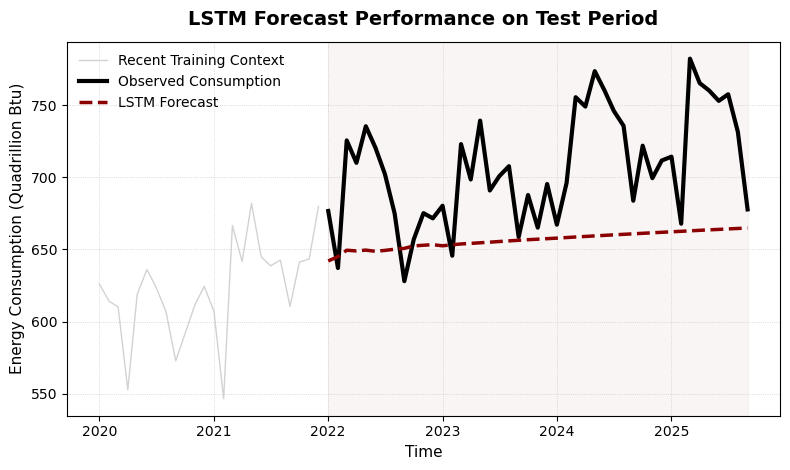

In [45]:
# ==================================================
# LSTM FORECAST VISUALIZATION (OUTSTANDING)
# ==================================================

fig, ax = plt.subplots(figsize=(8, 4.8))

# Context: last 24 months of training
context_window = 24
ax.plot(
    train.index[-context_window:],
    train[-context_window:],
    color="#c7c7c7",
    linewidth=1,
    alpha=0.8,
    label="Recent Training Context"
)

# Actual test values
ax.plot(
    test.index,
    test,
    color="black",
    linewidth=3,
    label="Observed Consumption"
)

# LSTM forecast
ax.plot(
    test.index,
    lstm_forecast,
    color="#8b0000",          # deep red (distinct from classical models)
    linestyle="--",
    linewidth=2.5,
    label="LSTM Forecast"
)

# Test period highlight
ax.axvspan(
    test.index.min(),
    test.index.max(),
    color="#8b0000",
    alpha=0.04
)

# Labels & title
ax.set_title(
    "LSTM Forecast Performance on Test Period",
    fontsize=14,
    fontweight="bold",
    pad=12
)
ax.set_xlabel("Time", fontsize=11)
ax.set_ylabel("Energy Consumption (Quadrillion Btu)", fontsize=11)

# Grid
ax.grid(True, linestyle=":", linewidth=0.6, alpha=0.6)

# Legend
ax.legend(frameon=False, fontsize=10, loc="upper left")

# Export
plt.tight_layout()
plt.savefig("fig_lstm_forecast_outstanding.png", dpi=300)
plt.show()


In [46]:
# ==================================================
# ROLLING-ORIGIN EVALUATION (STABILITY TEST)
# ==================================================

import numpy as np
import pandas as pd

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.seasonal import STL

from sklearn.metrics import mean_absolute_error, mean_squared_error

# --------------------------------------------------
# Settings
# --------------------------------------------------
horizon = 12          # 12-month forecast
step = 12             # move origin yearly

results = []

# Define rolling origins
origins = pd.date_range(
    start="2015-12-01",
    end="2021-12-01",
    freq="12MS"
)

# --------------------------------------------------
# Rolling-origin loop
# --------------------------------------------------
for origin in origins:
    
    train = y.loc[:origin]
    test = y.loc[origin + pd.DateOffset(months=1) :
                 origin + pd.DateOffset(months=horizon)]
    
    if len(test) < horizon:
        continue

    # ---------- SARIMA ----------
    sarima = SARIMAX(
        train,
        order=(1, 1, 1),
        seasonal_order=(1, 1, 1, 12),
        enforce_stationarity=False,
        enforce_invertibility=False
    )
    sarima_fit = sarima.fit(disp=False)
    sarima_fc = sarima_fit.forecast(horizon)

    results.append({
        "model": "SARIMA",
        "origin": origin,
        "MAE": mean_absolute_error(test, sarima_fc),
        "RMSE": np.sqrt(mean_squared_error(test, sarima_fc))
    })

    # ---------- ETS ----------
    ets = ExponentialSmoothing(
        train,
        trend="add",
        seasonal="add",
        seasonal_periods=12
    )
    ets_fit = ets.fit()
    ets_fc = ets_fit.forecast(horizon)

    results.append({
        "model": "ETS",
        "origin": origin,
        "MAE": mean_absolute_error(test, ets_fc),
        "RMSE": np.sqrt(mean_squared_error(test, ets_fc))
    })

    # ---------- STL-ARIMA ----------
    stl = STL(train, period=12, robust=True)
    stl_res = stl.fit()

    resid_model = SARIMAX(
        stl_res.resid.dropna(),
        order=(1, 0, 1),
        enforce_stationarity=False,
        enforce_invertibility=False
    )
    resid_fit = resid_model.fit(disp=False)
    resid_fc = resid_fit.forecast(horizon)

    seasonal_fc = np.tile(
        stl_res.seasonal[-12:], horizon // 12 + 1
    )[:horizon]

    trend_fc = np.repeat(stl_res.trend.iloc[-1], horizon)

    stl_fc = trend_fc + seasonal_fc + resid_fc.values

    results.append({
        "model": "STL-ARIMA",
        "origin": origin,
        "MAE": mean_absolute_error(test, stl_fc),
        "RMSE": np.sqrt(mean_squared_error(test, stl_fc))
    })

# --------------------------------------------------
# Results summary
# --------------------------------------------------
rolling_results = pd.DataFrame(results)

summary = (
    rolling_results
    .groupby("model")[["MAE", "RMSE"]]
    .agg(["mean", "std"])
)

print("Rolling-Origin Evaluation Summary:")
print(summary)


C:\Users\Kamal_FOM\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Kamal_FOM\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Kamal_FOM\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Kamal_FOM\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Kamal_FOM\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency

Rolling-Origin Evaluation Summary:
                 MAE                  RMSE           
                mean        std       mean        std
model                                                
ETS        20.417974   6.944060  24.570040   7.833484
SARIMA     19.755715  10.050194  22.964583  11.544520
STL-ARIMA  24.733306  10.266095  30.247485  12.104353
